## Image Captioning with Meta´s Llama

### Learning Objectives
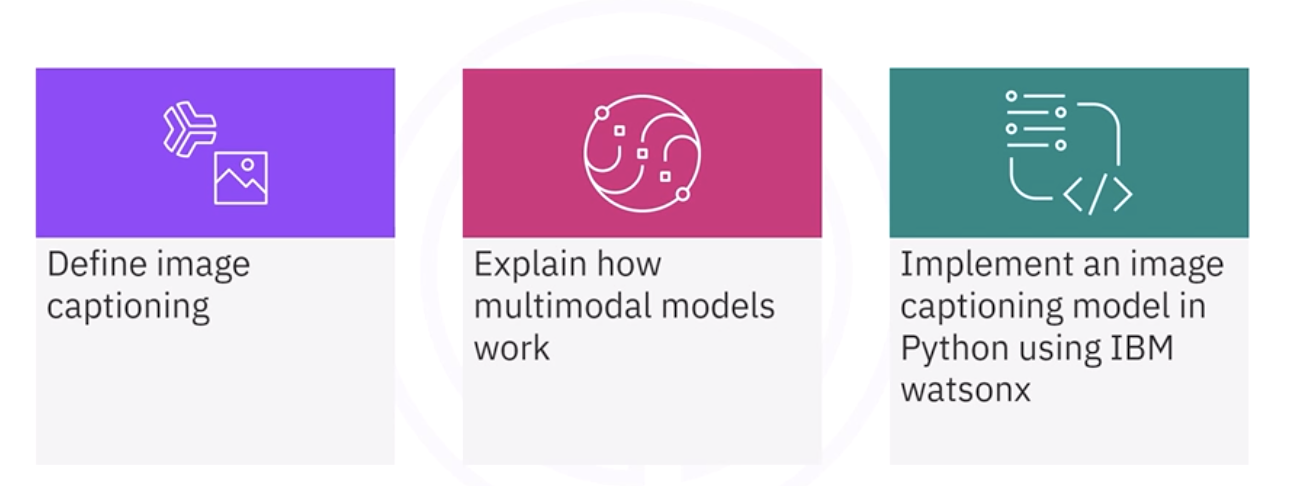

### sample usecase
- you may want to caption your 15 years collection of images
- Manual captioning based on year and holyday destination will take months
- image captioning with AI will take only minutes

### what is image captioning
- generate textual description of images
- Uses computer vison and NLP to generate meaningful information

### Image captioning with LLM
- requeries 3 steps
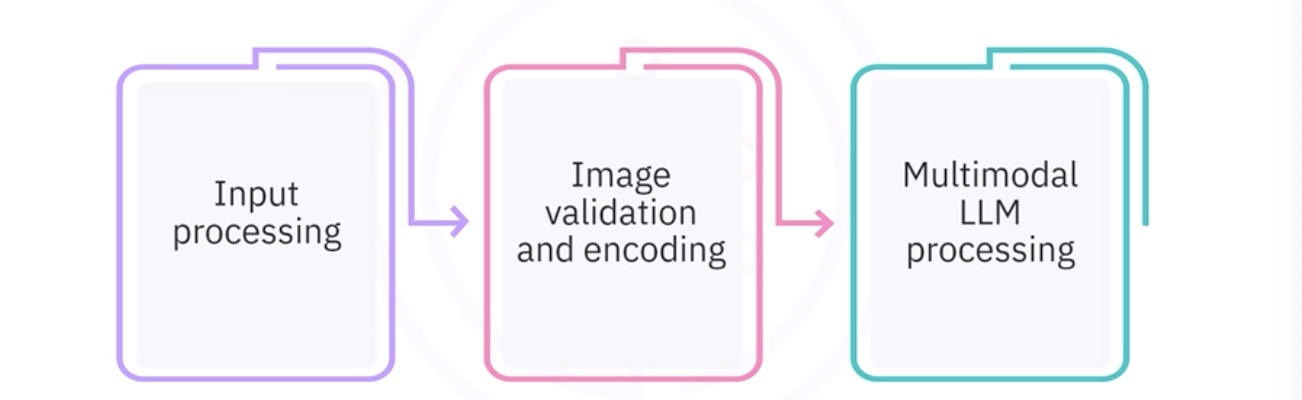

#### detailed diagram
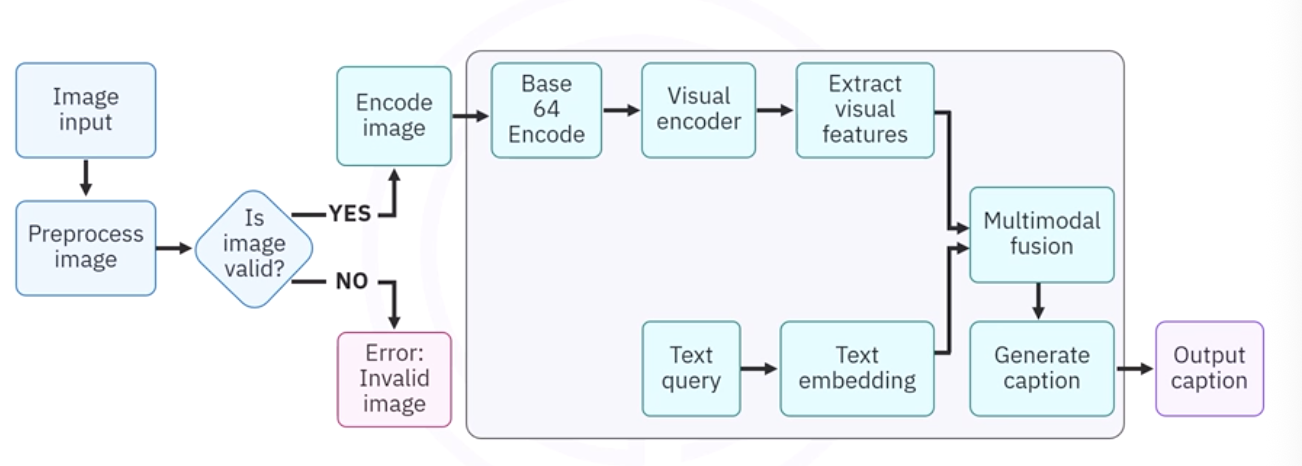
- during the stage of input processing system receives image and a prompt

- Preprocessing
    - image is normalized, resized, and optimized for the model
    - the text gives the information about the critical details we have to look in the image
    - during preprocssing the system validates the image (is it valid for further processing)
- once the image qualifes for futher processing, then the image is encoded (a base 64 encoded string)
    - the base 64 converstion is basically required for API calls
    - it is a mathematical conversion, not something model learned during training
        - the encoding captures
            - visuals
            - seens
            - relationships 
            - etc
- Visual encoder
    - Extracts meanigful information from the image
- Text encoder encodes the text 
- Multimodal fusion fuses the information from image and prompt 

### implemenation
    - CNN to encode image
    - RNN to generate caption

    
### implemenation

In [ ]:
import requests
import base64
import os
from ibm_watsonx_ai import Credentials
from ibm_watsibx_ai import APIClienet
from ibm_watsonx_ai.foundation_models import Model, ModelInference
from ibm_watsonx_ai.foundaton_models.schema import TextChatParameters
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames

from PIL import Image

# Setup credentials to IBM watsonx
credentials = Credentials(
    url = ...
    , api_key = ...
)

client = APIClienet(credentials)

# encode the images
encoded_images = []
for url in image_urls:
    encoded_images.append(
        base64.b64encode(
            requests.get(url).content
        )
    ).decode("utf-8")

# model
model_id = "meta-llama7llama-4-meverick-17b-128e-instruct-fp8"
project_id = "skills-network"
params = TextChatParameters()

model = ModelInference(
    model_id = model_id
    , credentials = credentials
    , project_id = project_id
    , params = params
)

def generate_model_response(
        encoded_image, 
        user_query, 
        assistant_prompt = "You are a helpful assistent. Answer the following user querz in 1 or 2 sentences:"):
    # create the message object
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": assistant_prompt + user_query
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "data:image/jepg;base64," + encoded_image,
                    }
                }
            ]
        }
    ]
    # send the request to the model
    response = model.chat(messages=messages)

    # Return the model response
    return response["choice"][0]["message"]["content"]

### model generating caption
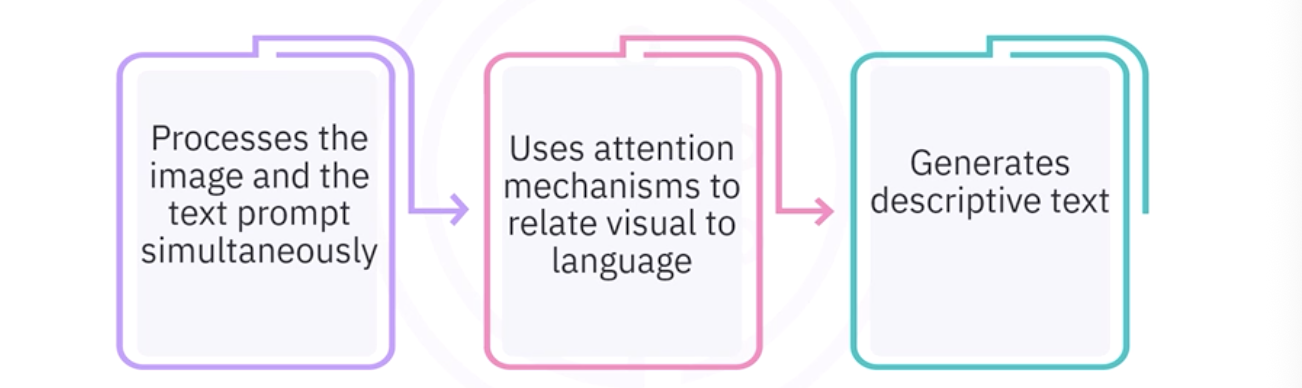

## Text to Vidoe models
- Text encoding
    - caputres the essenece of the prompt
- Latent space generation
    - diffussion models generate sequence of latent space representation curresponding to video frames. it start iwth random noise and iteratively refine it to produce meaningful context
- Temporal consistency
    - ensure somooth transition between frames, model incorporate temporal modules
        - 3D U-Nets: capturing spatial details and temporal dynamics
        - Transformers: self-attention mechanism to model dependencies across frames 
- Video decoding
    latent representation are decoded into actual video frames using decoder network (CNN)
- Frame interpolation (Optional)
    - some models use frame interpolation to generate intermediate frames between keyframes to achieve higher frame rates